First of all lets decide if the LGMB is better with or without windows

In [246]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import joblib
scale=StandardScaler()
import random
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
set_seed(42)

scale=StandardScaler()
results={}

In [247]:
#import dataframe
df_modelling=pd.read_parquet("../df_modelling.parquet")

In [248]:
numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']

print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days'],
      dtype='object')


In [249]:
x=df_modelling['embeddings_vector'][0]
print(f"Shape of the market vector {x.shape}")

Shape of the market vector (512,)


In [250]:
#Defining X and y
y = df_modelling['TargetVariable:Up/Down'].values
numerical_values=np.stack(df_modelling[numerical_columns].values)
embeddings_values=np.stack(df_modelling['embeddings_vector'].values)
X =np.concatenate((numerical_values, embeddings_values), axis=1)

In [251]:
#scaling
X_scaled=scale.fit_transform(X)

In [252]:
#defining a model
# Instantiate the LightGBM classifier
model = LGBMClassifier(
    boosting_type='gbdt',   # Gradient Boosting Decision Tree
    n_estimators=100,       # Number of trees
    learning_rate=0.1,      # Step size shrinkage
    max_depth=-1,           # No limit on tree depth
    num_leaves=31,          # Maximum number of leaves per tree
    random_state=42
)



In [253]:
def get_LGBM(X,y):
    
    #creating the splits for train & test
    split_at_train=int(X.shape[0]*0.7)
    split_at_val=int(X.shape[0]*0.9)
    X_train=X[:split_at_train]
    X_val=X[split_at_train:split_at_val]
    X_test=X[split_at_val:]
    y_train=y[:split_at_train]
    y_val=y[split_at_train:split_at_val]
    y_test=y[split_at_val:]
    #creating LGMB model
   
    model.fit(X_train, y_train)
    
    #making out the best threshold
    thresholds=np.arange(0.0,1.01,0.1)
    f1_scores=[]
    best_f1=0
    best_report=None
    #target performance score macro avg of f1_score 
    y_prob = model.predict_proba(X_val)[:,1]
    for threshold in thresholds:
        y_prob_tr = (y_prob > threshold).astype(int)
        report=classification_report(y_val, y_prob_tr, output_dict=True)
        f1=report['macro avg']['f1-score']
        f1_scores.append(report['macro avg']['f1-score'])
        

    f1_score=max(f1_scores)
    index_tr=f1_scores.index(f1_score)
    threshold=thresholds[index_tr]
    
    #testing on test data
    y_prob=model.predict_proba(X_test)[:,1]
    y_pred=(y_prob > threshold).astype(int)

    report=classification_report(y_test, y_pred, output_dict=True)
    f1=report['macro avg']['f1-score']
    print(f"Best Result is f1 {f1} at threshold {threshold}")
    best_cm=confusion_matrix(y_test, y_pred)

    print(classification_report(y_test, y_pred))
    auc=roc_auc_score(y_test, y_prob)

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')  # random line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right',bbox_to_anchor=(1,-0.2), facecolor='none')
    plt.title("ROC for Logistic Regression")
    #plt.savefig(f"ROC curve {str(text)}.png", bbox_inches='tight', transparent=True)
    plt.show()
    
    return f1,threshold, best_report, best_cm, model

    
    



[LightGBM] [Info] Number of positive: 168, number of negative: 175
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013804 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32471
[LightGBM] [Info] Number of data points in the train set: 343, number of used features: 469
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.489796 -> initscore=-0.040822
[LightGBM] [Info] Start training from score -0.040822
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/Users/irtg/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and be

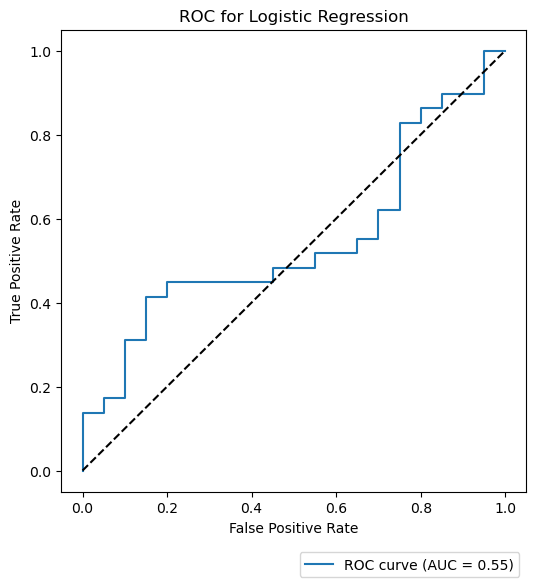

In [254]:
# Stack the market vectors into a 2D array 
f1,threshold,report,cm, model=get_LGBM(X_scaled,y)
results['without window']={
                "f1_score": f1,
                "threshold":threshold,
                "best_report":report, 
                "confusion_matrix":cm
}


In [255]:
#creating market vector
# 'Stock_Date', 'Closing Price($)', 'relative difference',
#        'comment_published_at_median_YMD', 'number_of_comments_at_date',
#        'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
#        'sentiment_tensor', 'videos_text_embeddings', 'TargetVariable:Up/Down'
numerical_columns=['Closing Price($) lag1',
'relative difference lag1',
         'number_of_comments_at_date',
    'comment_likes_agg',
    'comment_sentiment_agg',
     'sentiment_tensor']

print(df_modelling.columns)


#concating the embeddings separately
df_modelling['embeddings_vector']=df_modelling.apply(lambda row: np.concatenate((row['comment_embeddings_agg'], row['videos_text_embeddings_window'])), axis=1)
#concatenating the nummerical columns after that
#df_modelling['marketvector']=df_modelling.apply(lambda row: np.concatenate((row[numerical_columns].to_numpy(dtype=float),row['marketvector'])), axis=1)


Index(['Stock_Date', 'Closing Price($)', 'relative difference',
       'comment_published_at_YMD', 'number_of_comments_at_date',
       'comment_likes_agg', 'comment_embeddings_agg', 'comment_sentiment_agg',
       'sentiment_tensor', 'videos_text_embeddings', 'Difference',
       'videos_text_embeddings_window', 'TargetVariable:Up/Down',
       'Closing Price($) lag1', 'relative difference lag1',
       'Calendar_Diff_Days', 'embeddings_vector'],
      dtype='object')


In [256]:
x=df_modelling['embeddings_vector'][0]
print(f"Shape of the market vector {x.shape}")

Shape of the market vector (512,)


In [257]:
#Defining X and y
y = df_modelling['TargetVariable:Up/Down'].values
numerical_values=np.stack(df_modelling[numerical_columns].values)
embeddings_values=np.stack(df_modelling['embeddings_vector'].values)
X =np.concatenate((numerical_values, embeddings_values), axis=1)

In [258]:
#scaling
X_scaled=scale.fit_transform(X)

[LightGBM] [Info] Number of positive: 168, number of negative: 175
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36472
[LightGBM] [Info] Number of data points in the train set: 343, number of used features: 518
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.489796 -> initscore=-0.040822
[LightGBM] [Info] Start training from score -0.040822
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/irtg/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/irtg/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and be

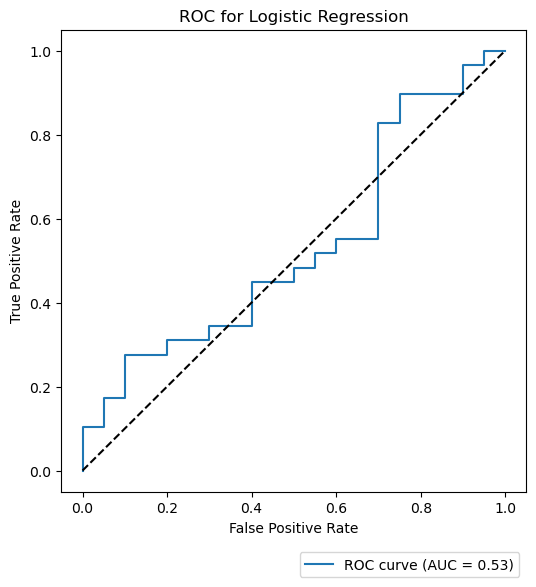

In [259]:
# Stack the market vectors into a 2D array 
f1,threshold, report,cm, model=get_LGBM(X_scaled,y)
results['with window']={"f1_score": f1,
                         'threshold':threshold,
                "best_report":report, 
                "confusion_matrix":cm
}


In [260]:
#saving the model with window for later
joblib.dump(model,"best_model_LGMB.joblib")

['best_model_LGMB.joblib']

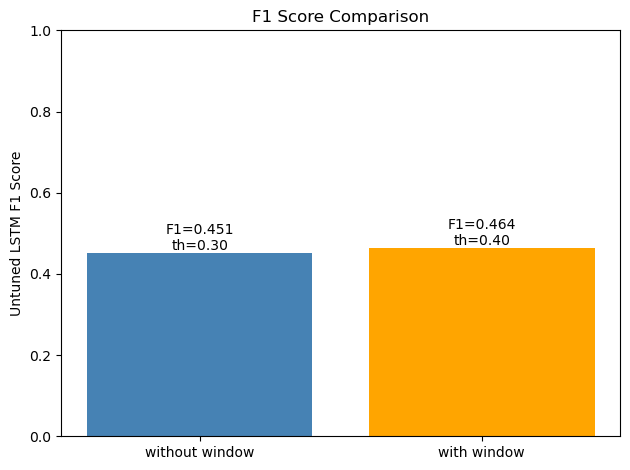

In [261]:
labels = list(results.keys())

f1_scores = [v['f1_score'] for v in results.values()]
thresholds = [v['threshold'] for v in results.values()]

bars = plt.bar(labels, f1_scores, color=["steelblue", "orange"])

plt.ylabel("Untuned LSTM F1 Score")
plt.title("F1 Score Comparison")
plt.ylim(0, 1)

# Add F1 + threshold as text
for bar, f1, th in zip(bars, f1_scores, thresholds):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"F1={f1:.3f}\nth={th:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Conclusion: With Window works better